[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sheik-info/gnn_project/blob/master/predict_link.ipynb)

**sujet du projet dnn:**


Prédiction de liens : En cachant certains liens, peut-on parvenir à les redécouvrir? Ce problème peut être évalué classiquement en utilisant l'AUC, Average Precision, Hits@k et MRR.

In [242]:
!pip install torch_geometric
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    roc_auc_score,
)

In [243]:
G = nx.read_graphml("airportsAndCoordAndPop.graphml")
#nx.draw(G, node_size=15)

In [244]:
data = from_networkx(G, group_node_attrs=["population", "lat", "lon"])


In [245]:
print(data)
print(data.keys())
print(data['edge_index'].shape)

Data(edge_index=[2, 27094], country=[3363], city_name=[3363], x=[3363, 3])
['x', 'city_name', 'edge_index', 'country']
torch.Size([2, 27094])


In [246]:
#on va essayer de deviner les noeuds des pays qui ont été supprimés
#on encode ce qu'on veut avoir en sortie y, ce qu'on veut deviner
encoder1 = LabelEncoder()
integer_labels = encoder1.fit_transform(data.country)
target_tensor1 = th.tensor(integer_labels, dtype=th.long)
print("target_tensor: ", target_tensor1)
data.y = target_tensor1
data.num_classes = len(set(data.country))

target_tensor:  tensor([ 66,  66,  66,  ...,  33, 143, 143])


In [247]:
# encoder2 = LabelEncoder()
# integer_labels = encoder2.fit_transform(data.city_name)
# target_tensor2 = th.tensor(integer_labels, dtype=th.long)
# print("target_tensor: ", target_tensor2)
# data.y = target_tensor2
# data.num_classes = len(set(data.city_name))

In [248]:
num_nodes = data.num_nodes
train_ratio = 0.70

# Randomly creating a mask
#va créer un dataset avec 70 % d'avoir true et 30% d'avoir false
mask = th.rand(num_nodes) < train_ratio
print("masks: ", mask.shape, mask.sum())
data.train_mask = mask
#inverse les true et les false
data.test_mask = ~data.train_mask

# remove the attributes for the nodes that are not in the training set
#mettre des 0 dans x pour ne pas avoir les préférences et pouvoir les prédire
temp = th.zeros((num_nodes, 3), dtype=th.float)
temp[data.train_mask] = data.x[data.train_mask]
data.x = temp
data
print(data.y)

masks:  torch.Size([3363]) tensor(2348)
tensor([ 66,  66,  66,  ...,  33, 143, 143])


On va utiliser le VGAE pour faire de la prédictiion de liens

In [249]:
#est non dirigé donc on a pas besoin de val_vgae mais on est obligé de le garder
#linksplit indispensable pour la prédiction de liens
transform = RandomLinkSplit(is_undirected=True)
train_vgae, val_vgae, test_vgae = transform(data)

In [250]:
#transformer la data compliqué en nombre

pos_edge_index = getattr(train_vgae, 'pos_edge_label_index', train_vgae.edge_label_index[:, train_vgae.edge_label == 1]).to(device)

class Encoder(nn.Module):
  def __init__(self, dim_in, dim_out):
    super().__init__()
    self.conv1 = GCNConv(dim_in, 2 * dim_out)
    self.conv2 = GCNConv(2 * dim_out,2 * dim_out)
    self.conv3 = GCNConv(2 * dim_out,2 * dim_out)
    self.conv_mu = GCNConv(2 * dim_out, dim_out)
    self.conv_logstd = GCNConv(2 * dim_out, dim_out)

  def forward(self, x, edge_index):
    x = self.conv1(x, edge_index).relu()
    x = self.conv2(x, edge_index).relu()
    x = self.conv3(x, edge_index).relu()
    return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

def train(model, data, epochs):
    model.train()
    optimizer.zero_grad()
    z = model.encode(train_vgae.x, train_vgae.edge_index)
    loss = model.recon_loss(z, pos_edge_index) + (1 / train_vgae.num_nodes) * model.kl_loss()
    loss.backward()
    #utilise le backward pour optimiser les parametres
    optimizer.step()

    return float(loss),

In [251]:
#chosis le hardware à utiliser cuda si c'est disponible sinon cpu
device = th.device('cuda' if th.cuda.is_available() else 'cpu')
model = VGAE(Encoder(data.num_features, 16)).to(device)
optimizer = th.optim.Adam(model.parameters(), lr=0.01)

In [252]:
# Nouvelle cellule pour ENTRAÎNER le modèle VGAE (Étape c)
# Sans cette étape, le modèle génère des probabilités totalement aléatoires.

# On s'assure d'avoir la variable train_data pour la fonction train définie plus haut
train_data = train_vgae.to(device)

print("Début de l'entraînement du modèle VGAE...")
for epoch in range(1, 1000):
    loss = train(model, train_data, epoch)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}")

print("Entraînement terminé !")

Début de l'entraînement du modèle VGAE...
Epoch: 001, Loss: 5951114.0000
Epoch: 020, Loss: 315534.0000
Epoch: 040, Loss: 394283.0000
Epoch: 060, Loss: 106752.6953
Epoch: 080, Loss: 87819.1016
Epoch: 100, Loss: 81693.3672
Epoch: 120, Loss: 71171.2812
Epoch: 140, Loss: 70345.8359
Epoch: 160, Loss: 70391.9141
Epoch: 180, Loss: 70195.9688
Epoch: 200, Loss: 157165.6250
Epoch: 220, Loss: 165859.8125
Epoch: 240, Loss: 142807.1250
Epoch: 260, Loss: 140467.8750
Epoch: 280, Loss: 140360.1719
Epoch: 300, Loss: 140318.2188
Epoch: 320, Loss: 140315.5781
Epoch: 340, Loss: 140314.5000
Epoch: 360, Loss: 140312.5000
Epoch: 380, Loss: 140311.4062
Epoch: 400, Loss: 140309.6250
Epoch: 420, Loss: 140307.6094
Epoch: 440, Loss: 140306.3438
Epoch: 460, Loss: 140303.8594
Epoch: 480, Loss: 142924.7656
Epoch: 500, Loss: 140633.9375
Epoch: 520, Loss: 140342.5312
Epoch: 540, Loss: 140381.6719
Epoch: 560, Loss: 140338.7188
Epoch: 580, Loss: 140319.9219
Epoch: 600, Loss: 140318.4219
Epoch: 620, Loss: 140317.8906
Epo

In [253]:
# Encoder les nœuds
z = model.encode(train_vgae.x.to(device), train_vgae.edge_index.to(device))

# Récupérer les indices d'arêtes de test (positives et négatives)
# S'assurer d'utiliser les bons attributs générés par le split
pos_edge_index = getattr(test_vgae, 'pos_edge_label_index', test_vgae.edge_label_index[:, test_vgae.edge_label == 1]).to(device)
neg_edge_index = getattr(test_vgae, 'neg_edge_label_index', test_vgae.edge_label_index[:, test_vgae.edge_label == 0]).to(device)

model.test(z, pos_edge_index, neg_edge_index)

(np.float64(0.4815359871889785), np.float64(0.49119816262489174))

In [254]:
#Check if it is able to reconstruct the original graph, by applying the dot product between
# node vectors. You can do it with something like:
pred_scores = th.sigmoid((z[pos_edge_index[0]] * z[pos_edge_index[1]]).sum(dim=1)).detach().numpy()

# how many edge are predicted with a score upon 0.5 ?
pred_demi = pred_scores > 0.5
print("Nombre d'arêtes prédites avec un score > 0.5 :", pred_demi.sum())

Nombre d'arêtes prédites avec un score > 0.5 : 1303


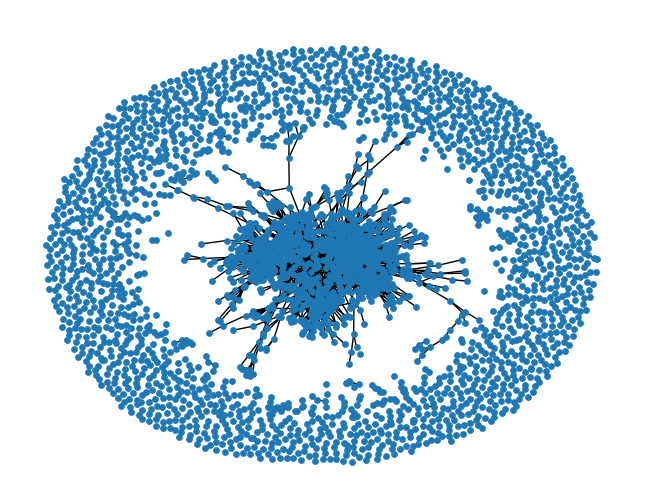

In [255]:
test_vgae.edge_index = pos_edge_index
new_G = to_networkx(test_vgae, to_undirected=True)

nx.draw(new_G, node_size=15)

In [257]:
# 1. Rassembler toutes les arêtes de test (positives et négatives)
test_edges = th.cat([pos_edge_index, neg_edge_index], dim=-1)

# 2. Calculer les prédictions (scores de probabilité) pour toutes ces arêtes
pred_scores_all = th.sigmoid((z[test_edges[0]] * z[test_edges[1]]).sum(dim=1)).detach().cpu().numpy()

# 3. Récupérer les vraies étiquettes de ces liens (1 pour positif, 0 pour négatif)
test_targets = test_vgae.edge_label.cpu().numpy()

# 4. Binariser les prédictions (seuil à 0.5)
pred_labels = (pred_scores_all > 0.5).astype(int)

# 5. Calculer le score de précision
pre_sc = accuracy_score(test_targets, pred_labels)
print("Precision Score:", pre_sc)

Precision Score: 0.48154300479881873
